# Z-Score Word Association Analysis — GPT-4o-mini Synthetic Data

Identifies which words are statistically associated with **FAVOR** or **AGAINST** stances for each political leader (Trump, Biden, Bernie Sanders) using a two-proportion Z-test.  
Also compares synthetic word associations with real P-Stance data to surface vocabulary injected by GPT-4o-mini that diverges from real discourse.

In [3]:
import os, sys

# ── Environment setup ──────────────────────────────────────────────────────────
REPO_URL  = 'https://github.com/milanvarghese/Political-Bias-Transfer-in-LLM-Generated-Training-Data.git'
REPO_NAME = 'Political-Bias-Transfer-in-LLM-Generated-Training-Data'

if 'google.colab' in sys.modules or os.path.exists('/content'):
    # Colab: clone repo into /content/ if not already there
    PROJ_ROOT = f'/content/{REPO_NAME}'
    if not os.path.isdir(PROJ_ROOT):
        os.system(f'git clone {REPO_URL} {PROJ_ROOT}')
else:
    # Local: try a list of known locations, then fall back to cwd
    candidates = [
        os.path.expanduser('~/Desktop/DSCI690/Final Project'),
        os.path.expanduser('~/Desktop/Git-repos/Political-Bias-Transfer-in-LLM-Generated-Training-Data'),
        os.getcwd(),
    ]
    PROJ_ROOT = next((p for p in candidates if os.path.isdir(p)
                      and os.path.isdir(os.path.join(p, 'data'))), os.getcwd())

os.chdir(PROJ_ROOT)
print('Working dir:', os.getcwd())

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import Counter
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

SYN_PATH = 'data/synthetic_data/gpt-4o-mini-2024-07-18_synthetic_1200per_cell_20260427_225135.csv'
REAL_TRAIN_PATHS = {
    'Donald Trump':   'data/PStance/raw_train_trump.csv',
    'Joe Biden':      'data/PStance/raw_train_biden.csv',
    'Bernie Sanders': 'data/PStance/raw_train_bernie.csv',
}
TARGETS   = ['Donald Trump', 'Joe Biden', 'Bernie Sanders']
MIN_OCCUR = 10
TOP_N     = 20

STOPWORDS = {
    'the','and','for','that','this','with','have','from','are','was','were',
    'not','but','they','their','all','has','can','will','its','been','more',
    'who','him','her','his','she','what','would','could','should',
    'also','just','like','about','when','out','over','there','then','than',
    'into','our','one','too','only','even','how','now','may','any','these',
    'some','your','had','let','get','got','did','does','say','said','take',
    'make','made','need','want','know','see','come','use','way','time','day',
    'man','men','people','year','good','new','first','last','long','great',
    'little','own','other','old','right','big','high','while','after','back',
    'look','think','around','another','came','every','between','both',
    'through','during','before','never','under','might','such','each','much',
    'those','though','still','very','where','here','because','against',
    'amp','rt','via','hey','lol','yes','yeah','actually','really','already',
    'ever','again','must','most','least','well','however','always',
    'ive','dont','wont','cant','isnt','wasnt','doesnt','didnt','arent',
    'won','run','ran','put','set','let','says','told','goes','keep',
    'stop','ask','trying','doing','going','saying','getting','making','giving',
    'using','taking','coming','looking','following','including','being',
    'nothing','something','everything','anything','someone','everyone',
    'anyone','nobody','somebody',
}

Working dir: C:\Users\milan\Desktop\DSCI690\Final Project


In [4]:
syn_df = pd.read_csv(SYN_PATH)
print('Synthetic data shape:', syn_df.shape)
print(syn_df.groupby(['Target', 'Stance']).size().rename('count').to_string())

real_frames = []
for target, path in REAL_TRAIN_PATHS.items():
    frame = pd.read_csv(path)[['Tweet', 'Target', 'Stance']]
    real_frames.append(frame)
real_df = pd.concat(real_frames, ignore_index=True)
print('\nReal P-Stance train shape:', real_df.shape)
print(real_df.groupby(['Target', 'Stance']).size().rename('count').to_string())

Synthetic data shape: (7200, 8)
Target          Stance 
Bernie Sanders  AGAINST    1200
                FAVOR      1200
Donald Trump    AGAINST    1200
                FAVOR      1200
Joe Biden       AGAINST    1200
                FAVOR      1200

Real P-Stance train shape: (17224, 3)
Target          Stance 
Bernie Sanders  AGAINST    2198
                FAVOR      2858
Donald Trump    AGAINST    3425
                FAVOR      2937
Joe Biden       AGAINST    3254
                FAVOR      2552


In [5]:
def tokenize(text):
    """Lowercase, strip URLs/mentions, keep hashtag words, filter stopwords."""
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r'http\S+', ' ', text)     # remove URLs
    text = re.sub(r'@\w+', ' ', text)         # remove mentions
    text = re.sub(r'#', ' ', text)            # strip # but keep word (e.g. #maga -> maga)
    tokens = re.findall(r"[a-z][a-z']{2,}", text)
    return [t for t in tokens if t not in STOPWORDS]

syn_df['tokens'] = syn_df['Tweet'].apply(tokenize)
real_df['tokens'] = real_df['Tweet'].apply(tokenize)
print('Tokenization done.')
print('Sample synthetic tokens:', syn_df['tokens'].iloc[0])

Tokenization done.
Sample synthetic tokens: ["i've", 'impressed', "trump's", 'bold', 'leadership', 'strong', 'stance', 'economy', 'policies', 'created', 'jobs', 'boosted', 'pride', 'nation', 'kind', 'energy', 'office', 'maga']


## Cell 4 — Two-Proportion Z-Score: FAVOR vs AGAINST (per target)

For each word in the combined vocabulary of FAVOR+AGAINST tweets for a given target:

$$Z = \frac{p_1 - p_2}{\sqrt{\hat{p}(1-\hat{p})\left(\frac{1}{n_1}+\frac{1}{n_2}\right)}}$$

where $p_1$ = word frequency in FAVOR, $p_2$ = word frequency in AGAINST, $\hat{p}$ = pooled frequency.  
$Z > 0$ → word skews **FAVOR**; $Z < 0$ → word skews **AGAINST**.

In [6]:
def compute_zscore_favor_vs_against(df, min_occur=MIN_OCCUR):
    """
    Two-proportion Z-test on DOCUMENT frequency (tweet-level binary occurrence).

    Uses the number of tweets containing a word, not raw token counts, so
    each tweet is one independent Bernoulli trial — satisfying the independence
    assumption of the test.

    Returns: DataFrame sorted descending by Z.
      Z > 0  → word skews FAVOR
      Z < 0  → word skews AGAINST
    """
    favor_tweets   = df[df['Stance'] == 'FAVOR']['tokens'].tolist()
    against_tweets = df[df['Stance'] == 'AGAINST']['tokens'].tolist()
    n1 = len(favor_tweets)    # number of FAVOR tweets
    n2 = len(against_tweets)  # number of AGAINST tweets

    # Binary: count distinct tweets containing each word (not total occurrences)
    favor_doc   = Counter(word for tweet in favor_tweets   for word in set(tweet))
    against_doc = Counter(word for tweet in against_tweets for word in set(tweet))
    vocab = set(favor_doc) | set(against_doc)

    rows = []
    for word in vocab:
        f1 = favor_doc.get(word, 0)
        f2 = against_doc.get(word, 0)
        if f1 + f2 < min_occur:
            continue
        p1    = f1 / n1
        p2    = f2 / n2
        p_hat = (f1 + f2) / (n1 + n2)
        se    = np.sqrt(p_hat * (1 - p_hat) * (1/n1 + 1/n2))
        z     = (p1 - p2) / se if se > 0 else 0.0
        rows.append({'token': word, 'z': z, 'favor_n': f1, 'against_n': f2, 'total_n': f1 + f2})

    return pd.DataFrame(rows).sort_values('z', ascending=False).reset_index(drop=True)

zscore_syn  = {}
zscore_real = {}

for target in TARGETS:
    zscore_syn[target]  = compute_zscore_favor_vs_against(syn_df[syn_df['Target'] == target])
    zscore_real[target] = compute_zscore_favor_vs_against(real_df[real_df['Target'] == target])

print('Z-score tables computed (document-frequency basis).')
for target in TARGETS:
    tbl   = zscore_syn[target]
    short = target.split()[-1]
    favor_top   = tbl.head(5)['token'].tolist()
    against_top = tbl.tail(5)['token'].tolist()
    print(f'\n{short}: FAVOR top-5 → {favor_top}  |  AGAINST top-5 → {against_top}')

Z-score tables computed (document-frequency basis).

Trump: FAVOR top-5 → ['maga', 'america', 'strong', 'economy', 'trump']  |  AGAINST top-5 → ['leaders', 'divisive', 'division', 'chaos', 'notmypresident']

Biden: FAVOR top-5 → ['biden', 'climate', 'progress', 'future', 'forward']  |  AGAINST top-5 → ['inflation', 'same', 'empty', 'bidenfail', 'promises']

Sanders: FAVOR top-5 → ['feelthebern', 'healthcare', 'working', 'truly', 'fighting']  |  AGAINST top-5 → ['practical', 'ideas', 'notmycandidate', 'promises', 'solutions']


## Cell 5 — Within-Cell Z-Score vs Background (word salience)

For each (target, stance) cell, test whether a word is over-represented compared to the entire synthetic corpus background:

$$Z_{\text{sal}} = \frac{O - E}{\sqrt{E \cdot \left(1 - \frac{E}{N_{\text{cell}}}\right)}}$$

where $O$ = observed count in cell, $E = \frac{f_{\text{global}}}{N_{\text{all}}} \times N_{\text{cell}}$.

In [7]:
def compute_salience_zscore(cell_df, background_counter, background_total, min_occur=MIN_OCCUR):
    """
    Binomial salience Z-score: how much more often does a word appear in this
    cell than expected under the background distribution?

    Background is computed from the OTHER 6,000 tweets (leave-one-cell-out),
    so the focal cell does not inflate its own expected frequency.

    Z > 0 → over-represented; Z < 0 → under-represented.
    """
    cell_tokens = [t for tokens in cell_df['tokens'] for t in tokens]
    n_cell      = len(cell_tokens)
    cell_cnt    = Counter(cell_tokens)

    rows = []
    for word, obs in cell_cnt.items():
        if obs < min_occur:
            continue
        # Leave-one-cell-out background: subtract this cell's count from global
        bg_count = background_counter.get(word, 0) - obs
        bg_n     = background_total - n_cell
        if bg_n <= 0 or bg_count < 0:
            continue
        expected = (bg_count / bg_n) * n_cell
        if expected <= 0:
            continue
        denom  = np.sqrt(expected * (1 - expected / n_cell))
        z_sal  = (obs - expected) / denom if denom > 0 else 0.0
        rows.append({'token': word, 'z_salience': z_sal,
                     'observed': obs, 'expected': round(expected, 2)})

    return pd.DataFrame(rows).sort_values('z_salience', ascending=False).reset_index(drop=True)

all_tokens_bg = [t for tokens in syn_df['tokens'] for t in tokens]
bg_counter    = Counter(all_tokens_bg)
bg_total      = len(all_tokens_bg)

salience = {}
for target in TARGETS:
    for stance in ['FAVOR', 'AGAINST']:
        cell_df = syn_df[(syn_df['Target'] == target) & (syn_df['Stance'] == stance)]
        salience[(target, stance)] = compute_salience_zscore(cell_df, bg_counter, bg_total)

print('Salience Z-scores computed (leave-one-cell-out background).')
for target in TARGETS:
    short = target.split()[-1]
    for stance in ['FAVOR', 'AGAINST']:
        top5 = salience[(target, stance)].head(5)['token'].tolist()
        print(f'  {short} {stance}: {top5}')

Salience Z-scores computed (leave-one-cell-out background).
  Trump FAVOR: ['strength', 'trump', 'america', 'media', 'strong']
  Trump AGAINST: ['circus', 'lies', 'notagain', 'divisive', 'chaos']
  Biden FAVOR: ['steady', 'moving', 'biden', 'forwardtogether', 'experience']
  Biden AGAINST: ['promised', 'inflation', 'rising', 'prices', 'skyrocketing']
  Sanders FAVOR: ['income', 'fairer', 'healthcare', 'justice', 'universal']
  Sanders AGAINST: ['sound', 'unrealistic', 'sounds', 'dreams', 'lofty']


## Cell 6 — Bias Detection: Synthetic vs Real Word Associations

For each target, compare Z-scores from synthetic and real data across shared vocabulary:
- **Spearman ρ**: rank-order agreement between synthetic and real
- **Sign flips**: words where GPT-4o-mini associates the *opposite* stance direction vs real tweets
- **Injected words**: high-Z synthetic words absent from real top-50

In [8]:
SIGN_FLIP_MIN_Z = 1.0   # both |Z_syn| and |Z_real| must exceed this to count as a real flip

bias_comparison = {}

for target in TARGETS:
    syn_tbl  = zscore_syn[target].set_index('token')
    real_tbl = zscore_real[target].set_index('token')
    shared   = syn_tbl.index.intersection(real_tbl.index)

    merged = pd.DataFrame({
        'z_syn':         syn_tbl.loc[shared, 'z'],
        'z_real':        real_tbl.loc[shared, 'z'],
        'favor_n_syn':   syn_tbl.loc[shared, 'favor_n'],
        'against_n_syn': syn_tbl.loc[shared, 'against_n'],
    }).reset_index()   # index.name == 'token' → becomes column 'token' automatically

    merged['direction_syn']  = merged['z_syn'].apply(lambda z: 'FAVOR' if z > 0 else 'AGAINST')
    merged['direction_real'] = merged['z_real'].apply(lambda z: 'FAVOR' if z > 0 else 'AGAINST')

    # Only count as a sign flip when both Z-scores are meaningfully non-zero
    # (|Z| > 1 ≈ 1 std dev from null); pure noise near 0 is excluded
    merged['bias_flag'] = (
        (merged['direction_syn'] != merged['direction_real']) &
        (merged['z_syn'].abs()   > SIGN_FLIP_MIN_Z) &
        (merged['z_real'].abs()  > SIGN_FLIP_MIN_Z)
    )

    rho, pval = spearmanr(merged['z_syn'], merged['z_real'])

    real_top50 = set(real_tbl.nlargest(50, 'z').index)  | set(real_tbl.nsmallest(50, 'z').index)
    syn_top50  = set(syn_tbl.nlargest(50, 'z').index)   | set(syn_tbl.nsmallest(50, 'z').index)
    injected   = syn_top50 - real_top50
    missing    = real_top50 - syn_top50

    bias_comparison[target] = {
        'merged':   merged,
        'rho':      rho,
        'pval':     pval,
        'injected': sorted(injected),
        'missing':  sorted(missing),
    }
    short   = target.split()[-1]
    n_flips = merged['bias_flag'].sum()
    print(f'{short}: Spearman ρ={rho:.3f} (p={pval:.2e}), '
          f'sign flips (|Z|>{SIGN_FLIP_MIN_Z})={n_flips}/{len(merged)}, '
          f'injected={len(injected)}, missing={len(missing)}')

Trump: Spearman ρ=0.258 (p=6.61e-06), sign flips (|Z|>1.0)=49/297, injected=91, missing=91
Biden: Spearman ρ=0.355 (p=1.25e-08), sign flips (|Z|>1.0)=41/243, injected=92, missing=92
Sanders: Spearman ρ=0.440 (p=1.43e-15), sign flips (|Z|>1.0)=37/298, injected=86, missing=86


## Cell 7 — Visualizations

**Plot A**: Top-15 FAVOR/AGAINST words per target (Z-score bar chart)  
**Plot B**: Heatmap of Z-score salience across all 6 (target × stance) cells  
**Plot C**: Synthetic vs Real Z-score scatter with sign-flip colouring

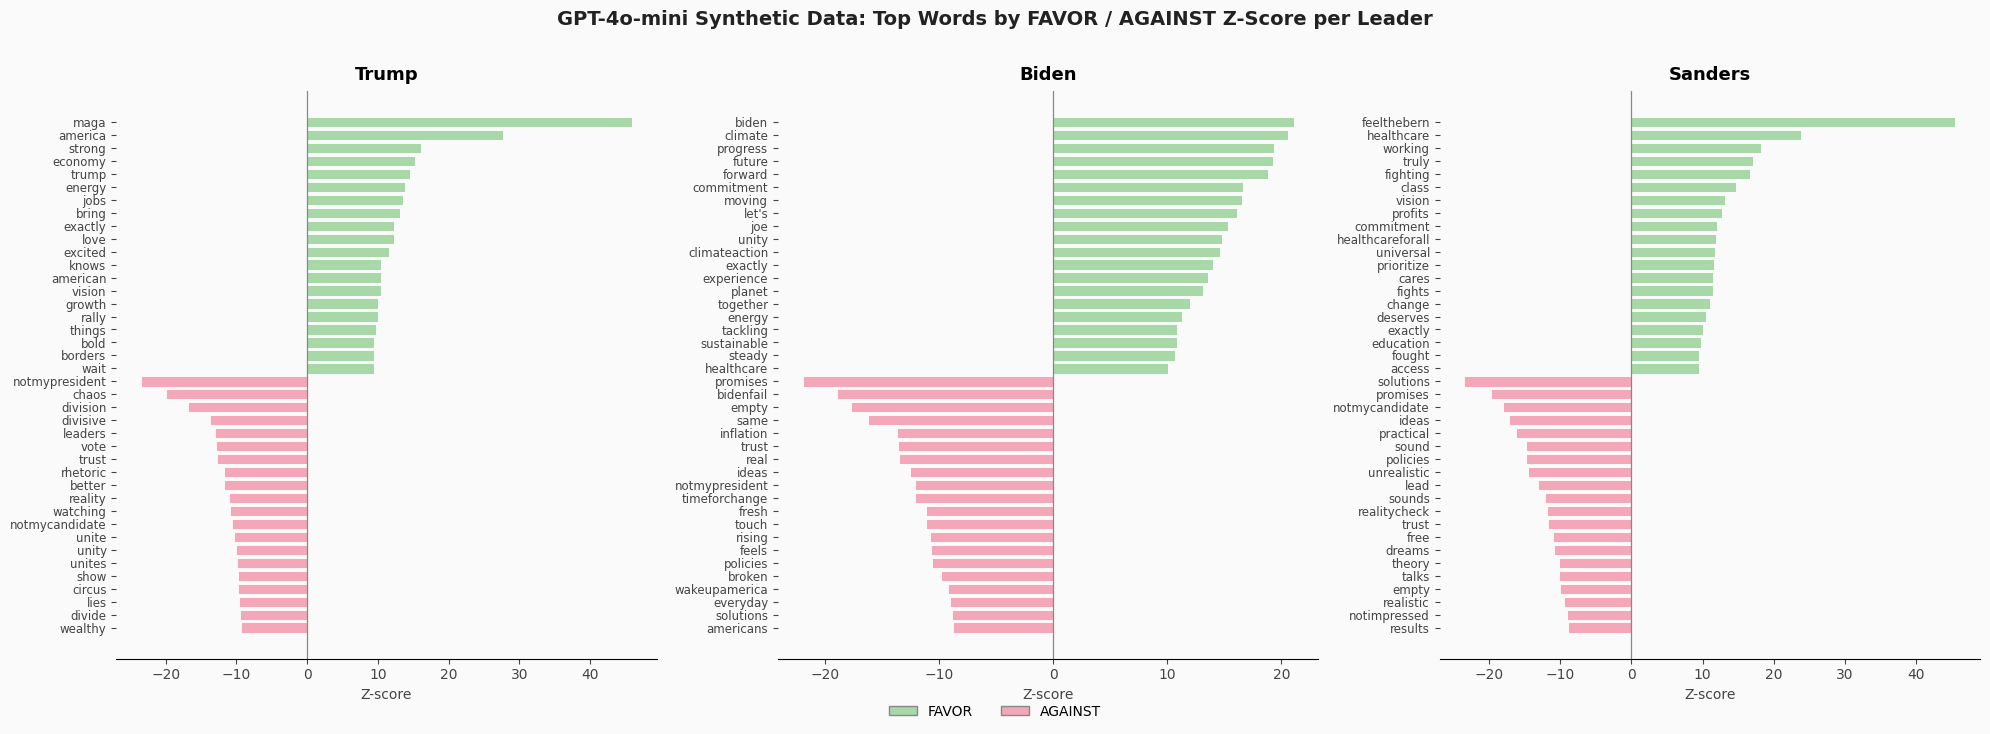

In [9]:
# ── Plot A: FAVOR vs AGAINST bar charts (one per target) ──────────────────────
import os
os.makedirs('plots', exist_ok=True)

FAVOR_COLOR   = '#A8D8A8'   # pastel mint-green
AGAINST_COLOR = '#F4A7B9'   # pastel rose-pink

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor='#FAFAFA')

for ax, target in zip(axes, TARGETS):
    tbl   = zscore_syn[target]
    short = target.split()[-1]

    favor_words   = tbl.head(TOP_N)[['token', 'z']].copy()
    against_words = tbl.tail(TOP_N)[['token', 'z']].copy().iloc[::-1]
    combined      = pd.concat([favor_words, against_words])
    colors        = [FAVOR_COLOR if z > 0 else AGAINST_COLOR for z in combined['z']]

    ax.set_facecolor('#FAFAFA')
    ax.barh(combined['token'], combined['z'], color=colors, edgecolor='white', linewidth=0.6)
    ax.axvline(0, color='#888888', linewidth=0.9)
    ax.set_title(f'{short}', fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel('Z-score', fontsize=10, color='#444444')
    ax.tick_params(axis='y', labelsize=8.5, colors='#444444')
    ax.tick_params(axis='x', colors='#444444')
    ax.spines[['top','right','left']].set_visible(False)
    ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=FAVOR_COLOR,   edgecolor='#888888', label='FAVOR'),
    Patch(facecolor=AGAINST_COLOR, edgecolor='#888888', label='AGAINST'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('GPT-4o-mini Synthetic Data: Top Words by FAVOR / AGAINST Z-Score per Leader',
             fontsize=14, fontweight='bold', y=1.01, color='#222222')
plt.tight_layout()
plt.savefig('plots/GPT4OMINI_plot_A_favor_against_zscores.png', dpi=150, bbox_inches='tight')
plt.show()

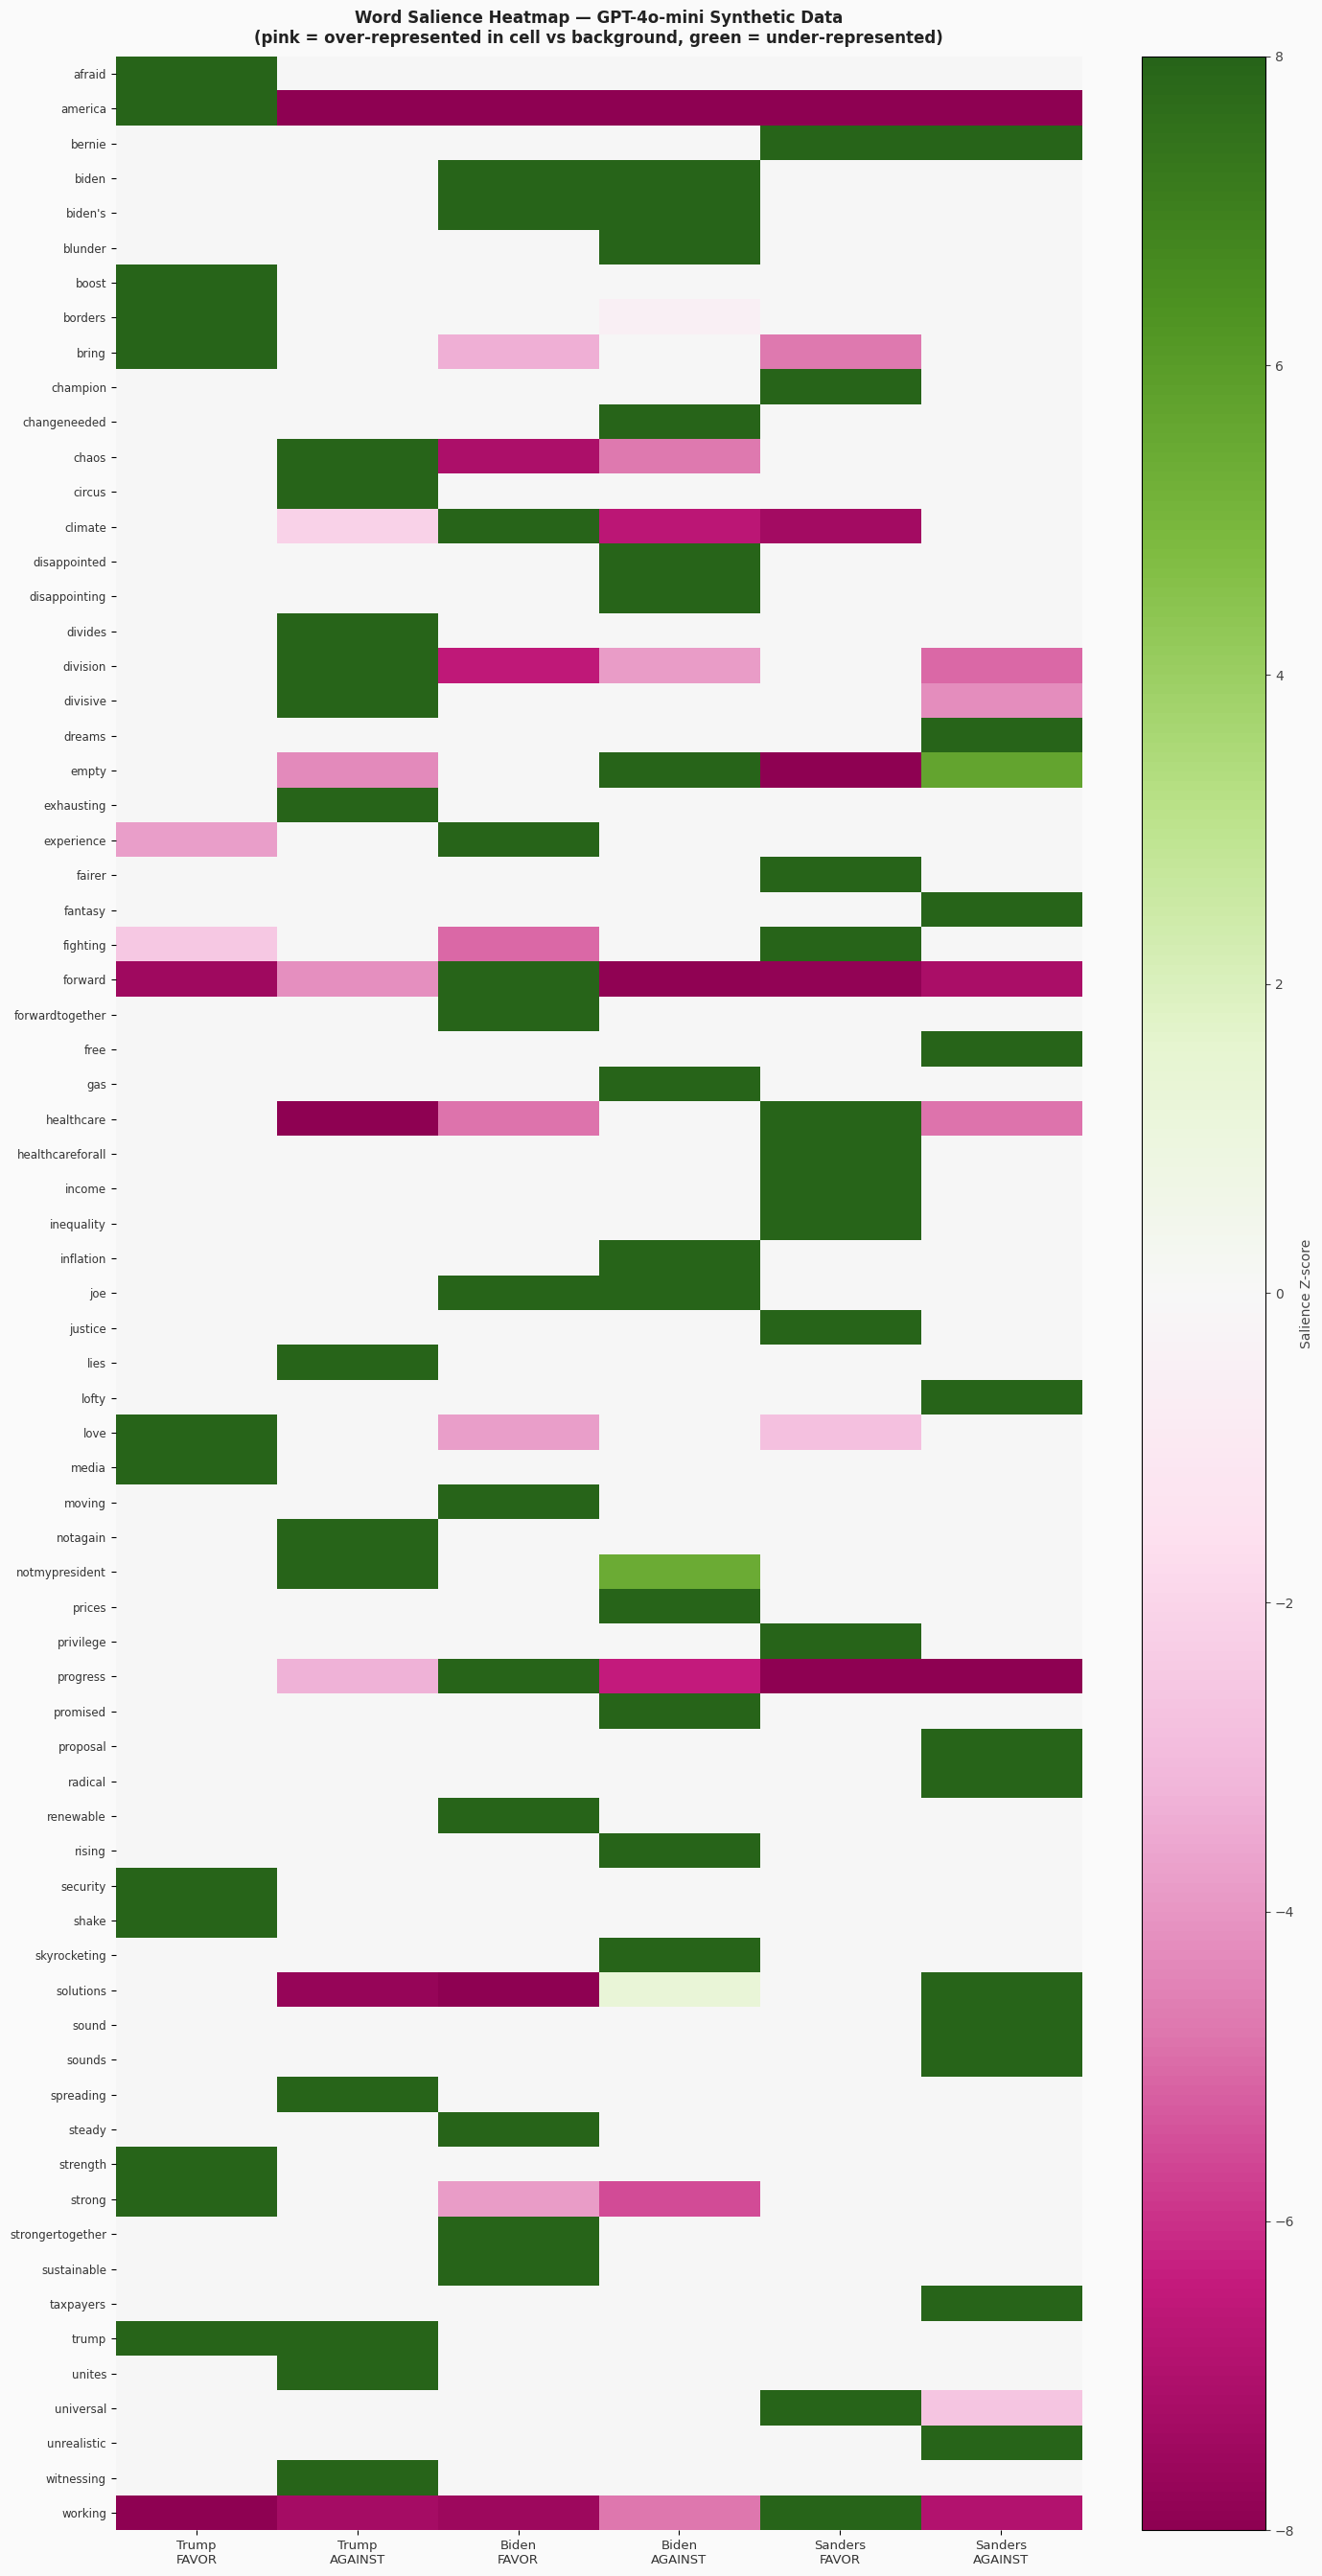

In [10]:
# ── Plot B: Salience heatmap across all 6 cells ───────────────────────────────
TOP_SAL    = 12
cell_order = [(t, s) for t in TARGETS for s in ['FAVOR', 'AGAINST']]
col_labels = [f"{t.split()[-1]}\n{s}" for t, s in cell_order]

top_words_union = set()
for key in cell_order:
    top_words_union.update(salience[key].head(TOP_SAL)['token'].tolist())
top_words = sorted(top_words_union)

heatmap_data = np.zeros((len(top_words), len(cell_order)))
for j, key in enumerate(cell_order):
    idx_map = salience[key].set_index('token')['z_salience'].to_dict()
    for i, word in enumerate(top_words):
        heatmap_data[i, j] = idx_map.get(word, 0.0)

fig, ax = plt.subplots(figsize=(14, max(8, len(top_words) * 0.38)), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')
im = ax.imshow(heatmap_data, aspect='auto', cmap='PiYG', vmin=-8, vmax=8)
ax.set_xticks(range(len(cell_order)))
ax.set_xticklabels(col_labels, fontsize=9.5, color='#333333')
ax.set_yticks(range(len(top_words)))
ax.set_yticklabels(top_words, fontsize=8.5, color='#333333')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Salience Z-score', fontsize=10, color='#444444')
cbar.ax.tick_params(colors='#444444')
ax.spines[:].set_visible(False)
ax.set_title('Word Salience Heatmap — GPT-4o-mini Synthetic Data\n'
             '(pink = over-represented in cell vs background, green = under-represented)',
             fontsize=12, fontweight='bold', color='#222222', pad=10)
plt.tight_layout()
plt.savefig('plots/GPT4OMINI_plot_B_salience_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

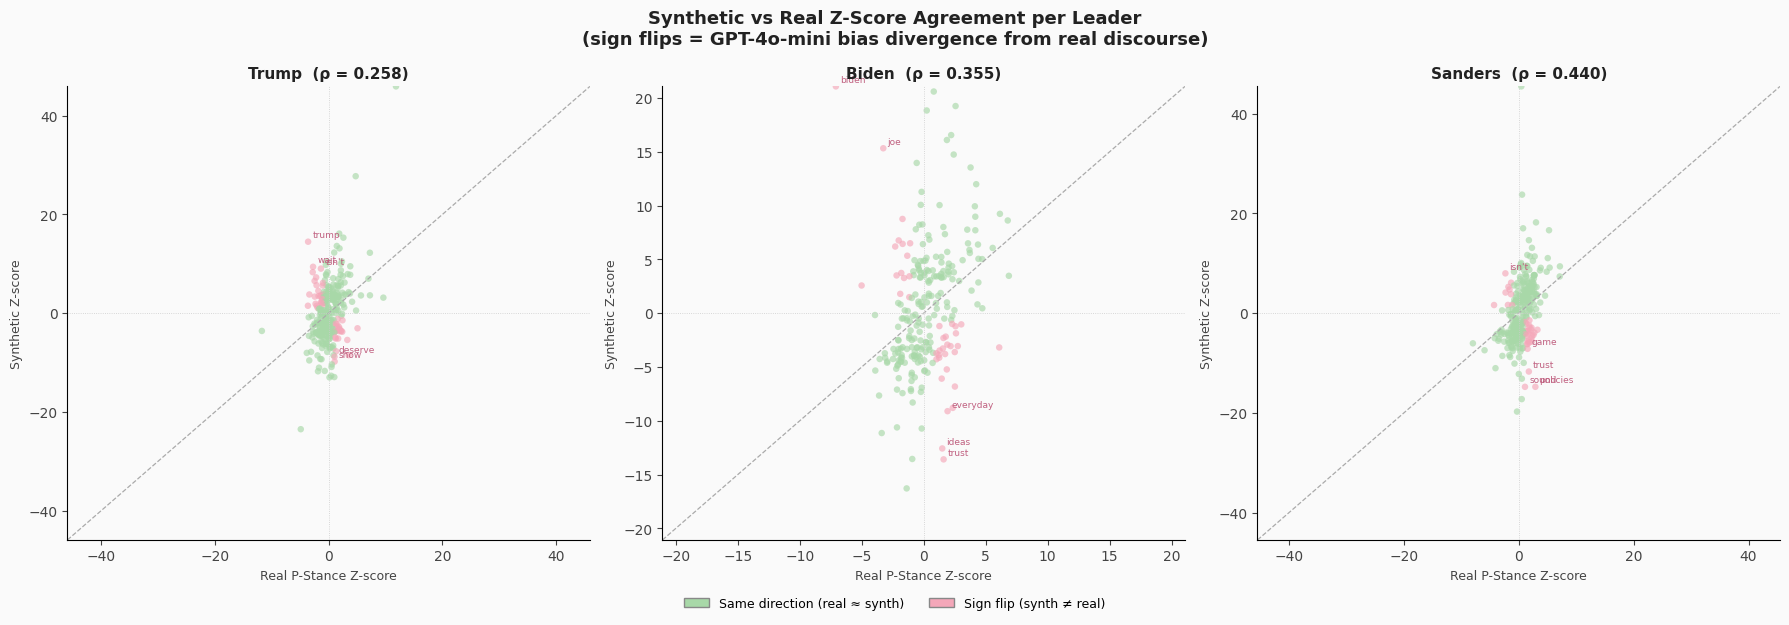

In [11]:
# ── Plot C: Synthetic vs Real Z-score scatter ─────────────────────────────────
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#FAFAFA')

for ax, target in zip(axes, TARGETS):
    bc    = bias_comparison[target]
    df_m  = bc['merged']
    rho   = bc['rho']
    short = target.split()[-1]

    colors = [AGAINST_COLOR if flipped else FAVOR_COLOR for flipped in df_m['bias_flag']]
    ax.set_facecolor('#FAFAFA')
    ax.scatter(df_m['z_real'], df_m['z_syn'], c=colors, alpha=0.65, s=22, edgecolors='none')

    lim = max(abs(df_m['z_real'].max()), abs(df_m['z_syn'].max()), 5)
    ax.plot([-lim, lim], [-lim, lim], color='#AAAAAA', linewidth=0.9, linestyle='--')
    ax.axhline(0, color='#CCCCCC', linewidth=0.6, linestyle=':')
    ax.axvline(0, color='#CCCCCC', linewidth=0.6, linestyle=':')

    # Label the 5 most extreme sign-flip words by |z_syn| (captures both directions)
    flips = (df_m[df_m['bias_flag']]
             .assign(abs_z_syn=lambda d: d['z_syn'].abs())
             .nlargest(5, 'abs_z_syn'))
    for _, row in flips.iterrows():
        ax.annotate(row['token'], (row['z_real'], row['z_syn']),
                    fontsize=6.5, color='#C06080',
                    xytext=(3, 3), textcoords='offset points')

    ax.set_title(f'{short}  (ρ = {rho:.3f})', fontsize=11, fontweight='bold', color='#222222')
    ax.set_xlabel('Real P-Stance Z-score', fontsize=9, color='#444444')
    ax.set_ylabel('Synthetic Z-score',     fontsize=9, color='#444444')
    ax.tick_params(colors='#444444')
    ax.spines[['top','right']].set_visible(False)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

legend_elements = [
    Patch(facecolor=FAVOR_COLOR,   edgecolor='#888888', label='Same direction (real ≈ synth)'),
    Patch(facecolor=AGAINST_COLOR, edgecolor='#888888', label='Sign flip (synth ≠ real)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('Synthetic vs Real Z-Score Agreement per Leader\n'
             '(sign flips = GPT-4o-mini bias divergence from real discourse)',
             fontsize=13, fontweight='bold', color='#222222')
plt.tight_layout()
plt.savefig('plots/GPT4OMINI_plot_C_syn_vs_real_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 8 — Summary Bias-Flag Tables

For each leader: top sign-flip words (synthetic and real Z-score disagree in direction), plus injected/missing vocabulary.

In [12]:
for target in TARGETS:
    bc    = bias_comparison[target]
    short = target.split()[-1]
    print(f'\n{'═'*70}')
    print(f'  {short.upper()}   Spearman ρ = {bc["rho"]:.3f}   p = {bc["pval"]:.2e}')
    print(f'{'═'*70}')

    # Sign-flip table (largest absolute z_syn among flipped words)
    flips = (bc['merged'][bc['merged']['bias_flag']]
             .assign(abs_z_syn=lambda d: d['z_syn'].abs())
             .nlargest(15, 'abs_z_syn')
             [['token', 'z_syn', 'z_real', 'direction_syn', 'direction_real']])

    if len(flips):
        print('  Top sign-flip words (synthetic direction ≠ real direction):')
        print(flips.to_string(index=False, float_format='{:.2f}'.format))
    else:
        print('  No sign flips found.')

    print(f'\n  Injected words (synth top-50, absent from real top-50):')
    print('  ', ', '.join(bc['injected'][:20]) or 'none')
    print(f'\n  Missing words (real top-50, absent from synth top-50):')
    print('  ', ', '.join(bc['missing'][:20]) or 'none')

print('\n' + '─'*70)
print('Analysis complete.')


══════════════════════════════════════════════════════════════════════
  TRUMP   Spearman ρ = 0.258   p = 6.61e-06
══════════════════════════════════════════════════════════════════════
  Top sign-flip words (synthetic direction ≠ real direction):
        token  z_syn  z_real direction_syn direction_real
        trump  14.48   -3.61         FAVOR        AGAINST
         show  -9.79    1.05       AGAINST          FAVOR
         wait   9.40   -2.74         FAVOR        AGAINST
        isn't   9.03   -1.36         FAVOR        AGAINST
      deserve  -8.81    1.03       AGAINST          FAVOR
wakeupamerica  -8.49    3.51       AGAINST          FAVOR
     security   8.30   -2.81         FAVOR        AGAINST
       choose  -7.72    1.31       AGAINST          FAVOR
      brought   7.25   -2.20         FAVOR        AGAINST
        money   6.54   -2.47         FAVOR        AGAINST
       afraid   6.13   -1.00         FAVOR        AGAINST
          why   5.66   -2.13         FAVOR        AGAIN